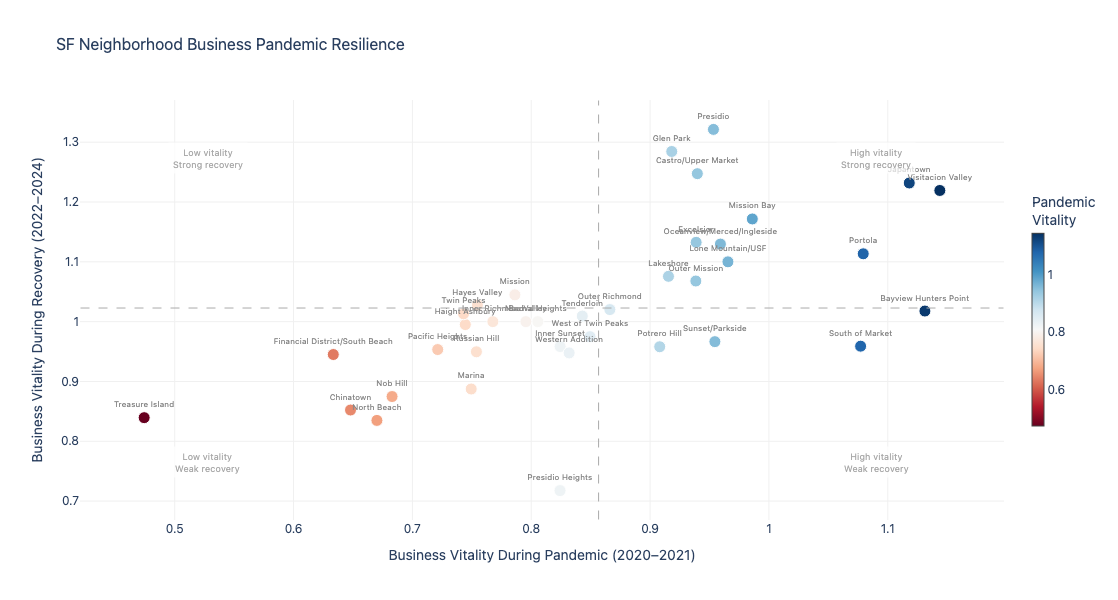

In [27]:
import pandas as pd
import geopandas as gpd
import plotly.graph_objects as go

gdf = gpd.read_parquet('../../data/processed/ALL_openings_closings_by_neighs_year.parquet')

gdf['open_close_ratio'] = gdf['opened'] / gdf['closed'].replace(0, float('nan'))

covid = (
    gdf[gdf['year'].between(2020, 2021)]
    .groupby('neighborhood')[['opened', 'closed']]
    .sum()
    .reset_index()
)
covid['covid_ratio'] = covid['opened'] / covid['closed'].replace(0, float('nan'))

recovery = (
    gdf[gdf['year'].between(2022, 2024)]
    .groupby('neighborhood')[['opened', 'closed']]
    .sum()
    .reset_index()
)
recovery['recovery_ratio'] = recovery['opened'] / recovery['closed'].replace(0, float('nan'))

biz_totals = (
    gdf[gdf['year'].between(2020, 2024)]
    .groupby('neighborhood')[['opened', 'closed']]
    .sum()
    .reset_index()
)
biz_totals['total'] = biz_totals['opened'] + biz_totals['closed']
active_neighs = biz_totals[biz_totals['total'] >= 500]['neighborhood']

df = covid[['neighborhood', 'covid_ratio']].merge(
    recovery[['neighborhood', 'recovery_ratio']], on='neighborhood'
)
df = df[df['neighborhood'].isin(active_neighs)]

x_mean = df['covid_ratio'].mean()
y_mean = df['recovery_ratio'].mean()
x_min, x_max = df['covid_ratio'].min(), df['covid_ratio'].max()
y_min, y_max = df['recovery_ratio'].min(), df['recovery_ratio'].max()
x_pad = (x_max - x_min) * 0.08
y_pad = (y_max - y_min) * 0.08

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['covid_ratio'],
    y=df['recovery_ratio'],
    mode='markers+text',
    text=df['neighborhood'],
    textposition='top center',
    textfont=dict(size=8, color='#888'),
    hovertemplate='<b>%{text}</b><br>Pandemic vitality: %{x:.2f}<br>Recovery vitality: %{y:.2f}<extra></extra>',
    marker=dict(
        size=12,
        color=df['covid_ratio'],
        colorscale='RdBu',
        cmin=df['covid_ratio'].min(),
        cmax=df['covid_ratio'].max(),
        showscale=True,
        colorbar=dict(title='Pandemic<br>Vitality', thickness=12, len=0.6),
        line=dict(width=1, color='white')
    )
))

fig.add_shape(type='line', x0=x_mean, x1=x_mean, y0=y_min - y_pad, y1=y_max + y_pad,
              line=dict(dash='dash', color='#aaa', width=1))
fig.add_shape(type='line', x0=x_min - x_pad, x1=x_max + x_pad, y0=y_mean, y1=y_mean,
              line=dict(dash='dash', color='#aaa', width=1))

for x, y, text in [
    (x_max - x_pad, y_max - y_pad, 'High vitality<br>Strong recovery'),
    (x_min + x_pad, y_max - y_pad, 'Low vitality<br>Strong recovery'),
    (x_min + x_pad, y_min + y_pad, 'Low vitality<br>Weak recovery'),
    (x_max - x_pad, y_min + y_pad, 'High vitality<br>Weak recovery'),
]:
    fig.add_annotation(x=x, y=y, text=text, showarrow=False,
                       font=dict(size=9, color='#aaa'),
                       bgcolor='rgba(255,255,255,0.7)',
                       borderpad=4)

fig.update_layout(
    title=dict(text='SF Neighborhood Business Pandemic Resilience', font=dict(size=16)),
    xaxis=dict(
        title='Business Vitality During Pandemic (2020–2021)',
        showgrid=True, gridcolor='#f0f0f0',
        zeroline=False
    ),
    yaxis=dict(
        title='Business Vitality During Recovery (2022–2024)',
        showgrid=True, gridcolor='#f0f0f0',
        zeroline=False
    ),
    height=600,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='-apple-system, BlinkMacSystemFont, Segoe UI, sans-serif')
)

fig.show()

In [28]:
df_export = covid[['neighborhood', 'covid_ratio']].merge(
    recovery[['neighborhood', 'recovery_ratio']], on='neighborhood'
)
df_export = df_export[df_export['neighborhood'].isin(active_neighs)].dropna()
df_export.to_parquet('../../data/processed/pandemic_resilience.parquet', index=False)